<a href="https://colab.research.google.com/github/mennasherif14/multimodal-meme-analyzer/blob/main/BERT_Hateful_Meme_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT-Based Hateful Meme Detection System

---

## Project Overview

This notebook presents a complete end-to-end pipeline for detecting hateful content in internet memes using a combination of Natural Language Processing (NLP) and Optical Character Recognition (OCR) techniques.

---

### What is Hateful Meme Detection?

Internet memes are a dominant form of communication on social media platforms. While most memes are humorous or informative, a significant portion contain hateful, offensive, or harmful content targeting individuals or groups based on race, religion, gender, nationality, or other characteristics. Automated detection of such content is a critical challenge in content moderation at scale.

A meme is considered **hateful** when it uses text, imagery, or a combination of both to attack, demean, or promote hatred toward a person or group. The challenge lies in understanding the **multimodal** nature of memes, where the image and text together convey a meaning that neither alone would express.

---

### Why BERT?

**BERT (Bidirectional Encoder Representations from Transformers)** is a state-of-the-art pre-trained language model developed by Google. It is trained on massive text corpora using a masked language modeling objective, allowing it to capture deep bidirectional contextual relationships between words.

BERT is chosen for this task because:
- It understands context in both directions (left-to-right and right-to-left simultaneously).
- It has strong transfer learning capabilities for downstream classification tasks.
- It handles nuanced language, slang, and implicit hate speech better than traditional models.
- Fine-tuning BERT on domain-specific data produces strong classification performance.

---

### Why OCR?

Memes often embed their primary message as text overlaid directly on an image. A system that only reads the metadata text field may miss the actual hateful content embedded in the image itself. **Optical Character Recognition (OCR)** is used to extract this embedded text, providing an additional textual signal for classification.

This project uses **EasyOCR**, a robust deep learning-based OCR library that supports multiple languages and handles stylized meme fonts effectively.

---

### Multimodal Meme Understanding

True meme understanding is inherently **multimodal**. In this pipeline, we approximate multimodal understanding through the text channel by:
1. Using the **provided meme text** (from dataset metadata).
2. Extracting **OCR text** directly from the meme image.
3. **Combining both text sources** to create a richer textual representation.

This combined text is then passed to BERT for classification, allowing the model to reason over all available textual information associated with each meme.

---

### Pipeline Architecture

```
Meme Image + Metadata Text
        |
   +----+----+
   |         |
  OCR    Metadata Text
   |         |
   +----+----+
        |
  Combined Text
        |
  Text Preprocessing
        |
  BERT Tokenization
        |
  BERT Encoder
        |
  Dropout + Dense Layer
        |
  Classification (Hateful / Non-Hateful)
```

---
## Section 1: Library Installation

Install all required libraries. This cell is safe to re-run and suppresses verbose output.

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_f86cd1b27d11deb25836d40fa07b47c8 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle

!cp /content/drive/MyDrive/Meme_Project/kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          24157        523                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           3215         68                1  
kanchana1990/e-commerce-pokmon-card-pricing-data                    E-commerce  Pokémon  Card  Pricing Data                  23214  2026-05-08 17:43:05.640000            253         31

In [ ]:
# Install required packages for the project
# transformers: HuggingFace library for BERT and other transformer models
# easyocr: Deep learning-based OCR for extracting text from meme images
# torch / torchvision: PyTorch deep learning framework
# Other standard data science and visualization libraries

!pip install transformers --quiet
!pip install easyocr --quiet
!pip install torch torchvision --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet
!pip install opencv-python-headless --quiet

print("All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 32.8 MB/s eta 0:00:00
All libraries installed successfully.


---
## Section 2: Import Libraries

In [ ]:
# Standard library imports
import os
import re
import json
import random
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Image processing
import cv2

# PyTorch core
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

# HuggingFace Transformers
from transformers import BertTokenizer, BertModel

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# EasyOCR
import easyocr

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Section 3: Environment Setup

Configure the environment for reproducible and stable training. This includes GPU detection, random seed setup, and warning suppression.

In [ ]:
# Suppress unnecessary warnings to keep output clean
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# GPU Detection
# -------------------------------------------------------
# Use CUDA GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU detected. Training will run on CPU (slower).")

# -------------------------------------------------------
# Random Seed Setup
# -------------------------------------------------------
# Fix all random seeds for full reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

# -------------------------------------------------------
# Global Configuration
# -------------------------------------------------------
MAX_LEN        = 128       # Maximum token length for BERT
BATCH_SIZE     = 16        # Batch size (reduce to 8 if OOM errors occur)
EPOCHS         = 5         # Number of training epochs
LEARNING_RATE  = 2e-5      # Low learning rate to avoid catastrophic forgetting in BERT
DROPOUT_RATE   = 0.3       # Dropout probability for regularization
BERT_MODEL     = 'bert-base-uncased'   # Pre-trained BERT variant

print("Environment configuration complete.")

Using device: cuda
GPU Name: Tesla T4
GPU Memory: 15.64 GB
Random seed set to: 42
Environment configuration complete.


---
## Section 4: Dataset Loading

Load the merged dataset CSV file. The dataset combines entries from the Facebook Hateful Meme dataset and the 9gag meme dataset.

Expected columns:
- `img`: Relative path to the meme image file
- `text`: Text metadata associated with the meme
- `label`: Binary label (0 = Non-Hateful, 1 = Hateful)

In [ ]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
# Update this path to wherever your CSV file is located
# For Google Colab, upload the file or mount Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   DATASET_PATH = '/content/drive/MyDrive/merged_dataset.csv'

DATASET_PATH = '/content/drive/MyDrive/Meme_Project/merged_dataset.csv'  # Update path as needed

try:
    df = pd.read_csv(DATASET_PATH)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at '{DATASET_PATH}'.")
    print("Please upload merged_dataset.csv and update DATASET_PATH.")
    raise

# -------------------------------------------------------
# Basic Dataset Inspection
# -------------------------------------------------------
print(f"\nDataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['label'].value_counts())

Dataset loaded successfully.

Dataset Shape: (9487, 5)
Number of samples: 9487
Number of columns: 5

Column Names:
['id', 'img', 'label', 'text', 'weight']

First 5 rows:


,id,img,label,text,weight
0,0,/content/data/img/27613.png,0,april 15th is coming... bitches better have my...,1.0
1,1,/content/data/img/10932.png,0,you come home and found this.. what do you do ???,1.0
2,2,/content/data/img/73980.png,0,i caught my goat cheating on me,1.0
3,3,/content/data/img/06823.png,1,removes polish with chemicals nobody bats an e...,1.0
4,4,/content/data/img/91385.png,0,you can tell the gender of an ant by throwing ...,1.0



Data Types:
id          int64
img        object
label       int64
text       object
weight    float64
dtype: object

Missing Values per Column:
id        0
img       0
label     0
text      1
weight    0
dtype: int64

Label Distribution:
label
0    6330
1    3157
Name: count, dtype: int64


---
## Section 5: Image Path Fixing

The merged dataset contains image paths from two different sources with different directory structures. This section defines a unified function to correctly resolve the full image path for any entry.

- **Facebook Hateful Meme dataset**: images stored under `img/` subdirectory
- **9gag dataset**: images stored under `9gag/` subdirectory

In [ ]:
# -------------------------------------------------------
# Image Root Directories
# -------------------------------------------------------
# Update these paths to match your actual data directory structure
# For Google Colab with Drive mounted:
#   FB_IMAGE_ROOT   = '/content/drive/MyDrive/data/'
#   GAGNINE_IMAGE_ROOT = '/content/drive/MyDrive/9gag/'

FB_IMAGE_ROOT     = './'       # Root directory for Facebook dataset images
GAGNINE_IMAGE_ROOT = './9gag/' # Root directory for 9gag dataset images


def resolve_image_path(img_path: str) -> str:
    """
    Resolve the full file system path for a meme image.

    Handles two dataset source structures:
    - Facebook Hateful Meme: paths like 'img/12345.png'
    - 9gag dataset: paths like '9gag/abc.jpg'

    Parameters
    ----------
    img_path : str
        The raw image path string from the dataset CSV.

    Returns
    -------
    str
        The resolved full path to the image file.
    """
    if not isinstance(img_path, str):
        return ''

    img_path = img_path.strip()

    # Already an absolute path
    if os.path.isabs(img_path) and os.path.exists(img_path):
        return img_path

    # 9gag dataset images
    if img_path.startswith('9gag'):
        candidate = os.path.join(GAGNINE_IMAGE_ROOT, os.path.basename(img_path))
        if os.path.exists(candidate):
            return candidate
        return os.path.join(GAGNINE_IMAGE_ROOT, img_path)

    # Facebook dataset: paths like 'img/01234.png'
    candidate = os.path.join(FB_IMAGE_ROOT, img_path)
    if os.path.exists(candidate):
        return candidate

    # Fallback: return joined path even if not found
    return os.path.join(FB_IMAGE_ROOT, img_path)


# Apply the path resolver to every image entry in the dataset
df['img_path'] = df['img'].apply(resolve_image_path)

# Check how many images can actually be found on disk
df['img_exists'] = df['img_path'].apply(os.path.exists)

print(f"Total entries: {len(df)}")
print(f"Images found on disk: {df['img_exists'].sum()}")
print(f"Images not found: {(~df['img_exists']).sum()}")
print("\nSample resolved paths:")
print(df[['img', 'img_path', 'img_exists']].head(10))

---
## Section 6: Exploratory Data Analysis (EDA)

Perform thorough exploratory analysis to understand the dataset distribution, class balance, text lengths, and sample content before modeling.

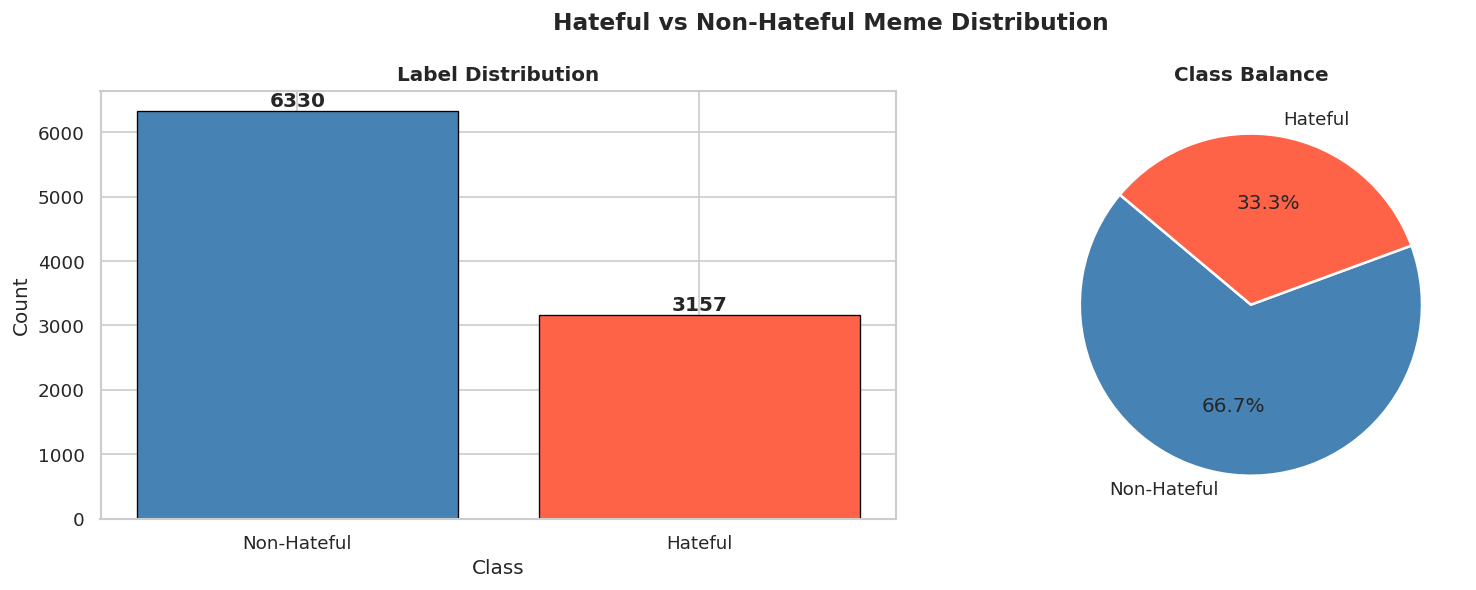

Label counts: {'Non-Hateful': np.int64(6330), 'Hateful': np.int64(3157)}


In [ ]:
# -------------------------------------------------------
# Plot Style Configuration
# -------------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

# -------------------------------------------------------
# Label Distribution
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['label'].value_counts().sort_index()
label_names  = {0: 'Non-Hateful', 1: 'Hateful'}
label_labels = [label_names.get(i, str(i)) for i in label_counts.index]

# Bar chart
bars = axes[0].bar(label_labels, label_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Label Distribution', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_labels,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('Hateful vs Non-Hateful Meme Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight')
plt.show()
print("Label counts:", dict(zip(label_labels, label_counts.values)))

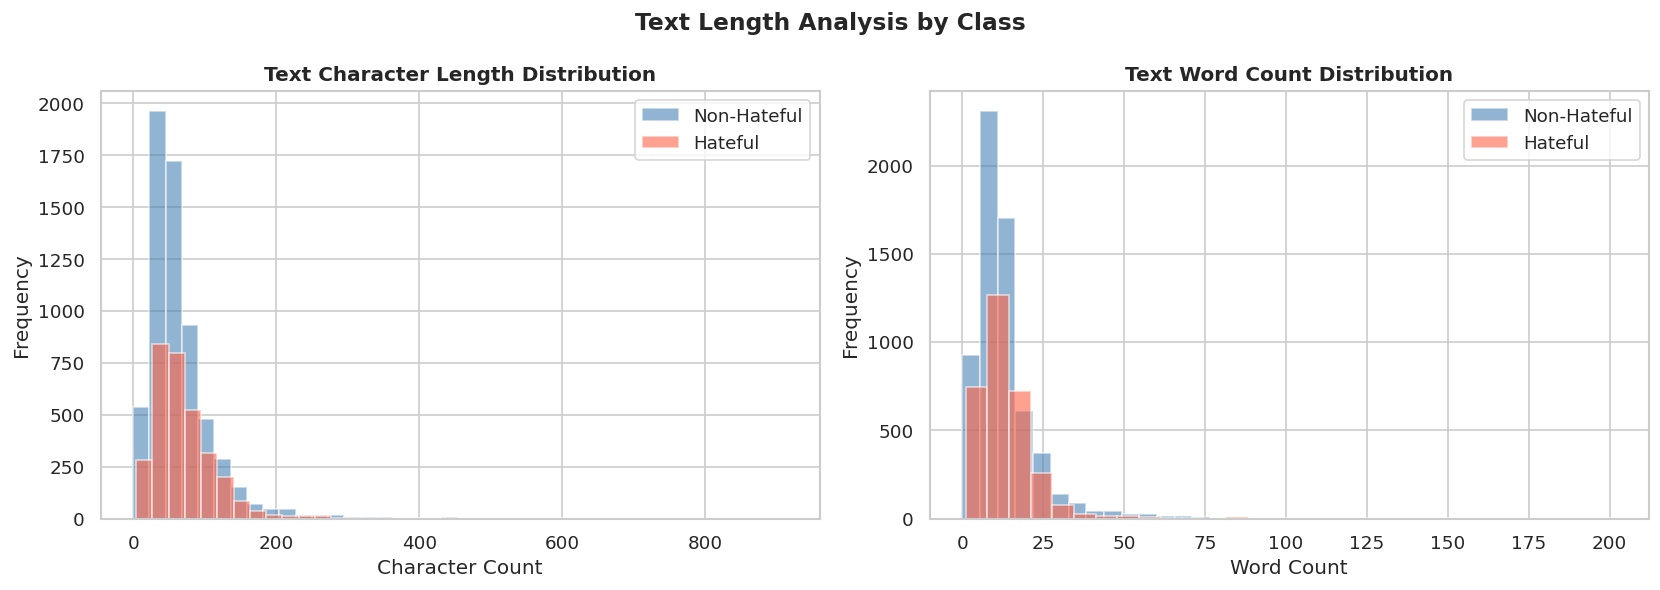

Average character length by label:
label
Non-Hateful    65.432701
Hateful        72.833703
Name: text_length, dtype: float64

Average word count by label:
label
Non-Hateful    13.039968
Hateful        13.774469
Name: word_count, dtype: float64


In [ ]:
# -------------------------------------------------------
# Text Length Distribution
# -------------------------------------------------------
# Fill missing text values before computing lengths
df['text_clean_temp'] = df['text'].fillna('').astype(str)
df['text_length']     = df['text_clean_temp'].apply(len)
df['word_count']      = df['text_clean_temp'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
for label_val, label_name, color in [(0, 'Non-Hateful', 'steelblue'), (1, 'Hateful', 'tomato')]:
    subset = df[df['label'] == label_val]['text_length']
    axes[0].hist(subset, bins=40, alpha=0.6, label=label_name, color=color, edgecolor='white')
axes[0].set_title('Text Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count distribution
for label_val, label_name, color in [(0, 'Non-Hateful', 'steelblue'), (1, 'Hateful', 'tomato')]:
    subset = df[df['label'] == label_val]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label_name, color=color, edgecolor='white')
axes[1].set_title('Text Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Text Length Analysis by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('text_length_distribution.png', bbox_inches='tight')
plt.show()

print("Average character length by label:")
print(df.groupby('label')['text_length'].mean().rename(label_names))

print("\nAverage word count by label:")
print(df.groupby('label')['word_count'].mean().rename(label_names))

In [ ]:
# -------------------------------------------------------
# Sample Text Examples
# -------------------------------------------------------
print("=" * 60)
print("SAMPLE NON-HATEFUL MEME TEXTS")
print("=" * 60)
non_hateful_samples = df[df['label'] == 0]['text'].dropna().sample(
    min(5, len(df[df['label'] == 0])), random_state=SEED
).tolist()
for i, text in enumerate(non_hateful_samples, 1):
    print(f"  [{i}] {text}")

print()
print("=" * 60)
print("SAMPLE HATEFUL MEME TEXTS")
print("=" * 60)
hateful_samples = df[df['label'] == 1]['text'].dropna().sample(
    min(5, len(df[df['label'] == 1])), random_state=SEED
).tolist()
for i, text in enumerate(hateful_samples, 1):
    print(f"  [{i}] {text}")

SAMPLE NON-HATEFUL MEME TEXTS
  [1] master chef with low rating master chef with high rating
  [2] i love pudding pudding my dick where it doesn't belong
  [3] i love to fight for my country
  [4] terrorist: islam me: what do you do? terrorist: slam slam my car car into people me:
  [5] rise of the planet of the apes (1963)

SAMPLE HATEFUL MEME TEXTS
  [1] the difference between moderate muslim and radical muslim moderate muslim follow my allah or i kill you! radical muslim follow my allah or he kill you
  [2] i asked him to see things from my point of view he looked out the kitchen window
  [3] kenyan shit
  [4] my husband is always pushing me around.... and talking behind my back
  [5] i never dated my cuz'n i fucked him but we never dated


In [ ]:
# -------------------------------------------------------
# Sample Text Examples
# -------------------------------------------------------

samples = df.sample(10, random_state=42)

for idx, row in samples.iterrows():

    label = "Hateful" if row['label'] == 1 else "Non-Hateful"

    print("=" * 60)

    print("Label:", label)

    print("Text:")

    print(row['text'])

    print()

Label: Hateful
Text:
remember when illegal aliens just wanted to just go home? now they want free food, healthcare, and housing

Label: Non-Hateful
Text:
sour candy will have you like 

Label: Non-Hateful
Text:
it's obvious that he's thinking about another girl i can't believe that the lamb's bride has been the new jerusalem this whole time

Label: Non-Hateful
Text:
pineapple on pizza in front of a confederate flag let's see how many people we can get pissed off

Label: Non-Hateful
Text:
companies when pride month ends

Label: Hateful
Text:
"never forget" - you said. i am the proof you have forgotten

Label: Non-Hateful
Text:
now whether it is fy barbie annabelle ar voodoo sars a roll of the dice

Label: Non-Hateful
Text:
who let the dogs out !

Label: Non-Hateful
Text:
happy birthday i made you a drink

Label: Non-Hateful
Text:
im this pretty because make up works miracles



---
## Section 8: Text Preprocessing

Define a `clean_text()` function to normalize all text inputs before feeding them to the BERT tokenizer. Consistent preprocessing is critical for model stability.

In [ ]:
def clean_text(text) -> str:
    """
    Clean and normalize input text for BERT processing.
    """

    # Handle NaN and None safely
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ''

    # Ensure string type
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+|www\\.\\S+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text)

    # Strip spaces
    text = text.strip()

    return text


# Apply preprocessing only on text column

df['text_cleaned'] = df['text'].apply(clean_text)

# Remove empty rows

df = df[
    df['text_cleaned'].str.strip() != ''
]

# Reset index

df = df.reset_index(drop=True)

print("Text preprocessing complete.")

print(df[['text', 'text_cleaned']].head())

Text preprocessing complete.
                                                text  \
0  april 15th is coming... bitches better have my...   
1  you come home and found this.. what do you do ???   
2                    i caught my goat cheating on me   
3  removes polish with chemicals nobody bats an e...   
4  you can tell the gender of an ant by throwing ...   

                                        text_cleaned  
0  april 15th is coming    bitches better have my...  
1      you come home and found this   what do you do  
2                    i caught my goat cheating on me  
3  removes polish with chemicals nobody bats an e...  
4  you can tell the gender of an ant by throwing ...  


---
## Section 9: Combine Text Features

Merge the cleaned metadata text and the OCR-extracted text into a single `combined_text` feature. This gives the BERT model access to all available textual information from each meme.

In [ ]:
# Use cleaned text directly for BERT input

df['combined_text'] = df['text_cleaned']

# Remove empty rows

df = df[
    df['combined_text'].str.strip() != ''
]

# Reset index

df = df.reset_index(drop=True)

# Statistics

empty_combined = (
    df['combined_text'] == ''
).sum()

print(f"Entries with text: {len(df) - empty_combined}")

print(f"Empty entries: {empty_combined}")

print("\nSample texts:")

print(
    df[['combined_text', 'label']]
    .head(5)
    .to_string()
)

Entries with text: 9486
Empty entries: 0

Sample texts:
                                                                                             combined_text  label
0    april 15th is coming    bitches better have my money    memegenerator ne bitches better have my money      0
1                                                            you come home and found this   what do you do      0
2                                                                          i caught my goat cheating on me      0
3  removes polish with chemicals nobody bats an eye removes polish with chemicals everybody loses his shit      1
4  you can tell the gender of an ant by throwing it in water if it sinks  girl ant   if it floats  buoyant      0


---
## Section 10: Dataset Cleaning

Remove invalid, incomplete, or ambiguous entries before modeling. This includes rows with missing text, invalid labels, or duplicate entries.

In [ ]:
print(f"Dataset size before cleaning: {len(df)}")

# -------------------------------------------------------
# Step 1: Remove rows with empty combined text
# -------------------------------------------------------
df = df[df['combined_text'].str.strip() != '']
print(f"After removing empty combined text: {len(df)}")

# -------------------------------------------------------
# Step 2: Remove rows with invalid or missing labels
# -------------------------------------------------------
# Keep only binary labels: 0 (Non-Hateful) and 1 (Hateful)
df = df[df['label'].isin([0, 1])]
print(f"After removing invalid labels: {len(df)}")

# -------------------------------------------------------
# Step 3: Remove duplicate entries
# -------------------------------------------------------
df = df.drop_duplicates(subset=['combined_text', 'label'])
print(f"After removing duplicates: {len(df)}")

# -------------------------------------------------------
# Step 4: Reset the index
# -------------------------------------------------------
df = df.reset_index(drop=True)

# -------------------------------------------------------
# Step 5: Ensure correct data types
# -------------------------------------------------------
df['label']         = df['label'].astype(int)
df['combined_text'] = df['combined_text'].astype(str)

print(f"\nFinal dataset size: {len(df)}")
print(f"Final label distribution:")
print(df['label'].value_counts().rename(label_names))

print("\nDataset integrity verified. Ready for modeling.")

Dataset size before cleaning: 9486
After removing empty combined text: 9486
After removing invalid labels: 9486
After removing duplicates: 8918

Final dataset size: 8918
Final label distribution:
label
Non-Hateful    5972
Hateful        2946
Name: count, dtype: int64

Dataset integrity verified. Ready for modeling.


---
## Section 11: Train / Validation / Test Split

Split the dataset into three stratified subsets:
- **Train**: 70% - used for model parameter updates
- **Validation**: 15% - used for hyperparameter tuning and early stopping
- **Test**: 15% - held out for final unbiased evaluation

Stratified splitting ensures class proportions are preserved in each split.

In [ ]:
# -------------------------------------------------------
# Extract features and labels
# -------------------------------------------------------
X = df['combined_text'].values  # Input text
y = df['label'].values           # Binary labels

# -------------------------------------------------------
# Step 1: Split into train (70%) and temp (30%)
# -------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

# -------------------------------------------------------
# Step 2: Split temp into validation (50%) and test (50%)
# Results in: 70% train / 15% val / 15% test
# -------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print(f"Train set size:      {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size:       {len(X_test)} samples")

print("\nClass distribution in splits:")
for split_name, labels in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    dist = dict(zip([label_names[u] for u in unique], counts))
    print(f"  {split_name}: {dist}")

Train set size:      6242 samples
Validation set size: 1338 samples
Test set size:       1338 samples

Class distribution in splits:
  Train: {'Non-Hateful': np.int64(4180), 'Hateful': np.int64(2062)}
  Validation: {'Non-Hateful': np.int64(896), 'Hateful': np.int64(442)}
  Test: {'Non-Hateful': np.int64(896), 'Hateful': np.int64(442)}


---
## Section 12: Tokenization

Load the **BertTokenizer** for `bert-base-uncased` and define tokenization parameters. BERT requires text to be converted into subword token IDs, along with attention masks that distinguish real tokens from padding.

In [ ]:
# -------------------------------------------------------
# Load Pre-trained BERT Tokenizer
# -------------------------------------------------------
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
print("Tokenizer loaded.")
print(f"Vocabulary size: {tokenizer.vocab_size}")

# -------------------------------------------------------
# Tokenization Demo
# -------------------------------------------------------
# Show how a sample text is tokenized before building the full dataset
sample_text = X_train[0] if len(X_train) > 0 else "this is a test meme text"
encoding    = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f"\nSample tokenization for: '{sample_text[:60]}...'")
print(f"  input_ids shape:      {encoding['input_ids'].shape}")
print(f"  attention_mask shape: {encoding['attention_mask'].shape}")
print(f"  Token count (non-pad): {encoding['attention_mask'].sum().item()}")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.
Vocabulary size: 30522

Sample tokenization for: 'islamic windchimes...'
  input_ids shape:      torch.Size([1, 128])
  attention_mask shape: torch.Size([1, 128])
  Token count (non-pad): 6


---
## Section 13: Custom PyTorch Dataset Class

Define a custom `torch.utils.data.Dataset` class that tokenizes text on-the-fly and returns the tensors required by the BERT model.

In [ ]:
class MemeTextDataset(Dataset):
    """
    PyTorch Dataset for meme text classification.

    Tokenizes input texts using BertTokenizer and returns
    dictionaries containing input tensors ready for BERT.

    Parameters
    ----------
    texts : array-like
        Array of raw input text strings.
    labels : array-like
        Array of binary integer labels (0 or 1).
    tokenizer : BertTokenizer
        Pre-loaded HuggingFace tokenizer instance.
    max_len : int
        Maximum sequence length for tokenization.
    """

    def __init__(self, texts, labels, tokenizer, max_len: int):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        """Return the total number of samples in the dataset."""
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        """
        Retrieve and tokenize a single sample.

        Returns
        -------
        dict with keys:
            'input_ids'      : LongTensor of shape [max_len]
            'attention_mask' : LongTensor of shape [max_len]
            'label'          : LongTensor scalar
        """
        # Safely retrieve and clean text at this index
        text  = clean_text(self.texts[idx])
        label = int(self.labels[idx])

        # Ensure text is not empty (protect against edge cases)
        if not text:
            text = 'empty'

        # Tokenize using BERT tokenizer
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # Shape: [max_len]
            'attention_mask': encoding['attention_mask'].squeeze(0),  # Shape: [max_len]
            'label':          torch.tensor(label, dtype=torch.long)   # Scalar
        }


# -------------------------------------------------------
# Instantiate Datasets
# -------------------------------------------------------
train_dataset = MemeTextDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = MemeTextDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = MemeTextDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f"Train dataset size:      {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size:       {len(test_dataset)}")

# Verify a single sample
sample = train_dataset[0]
print(f"\nSample batch keys:         {list(sample.keys())}")
print(f"input_ids shape:           {sample['input_ids'].shape}")
print(f"attention_mask shape:      {sample['attention_mask'].shape}")
print(f"label:                     {sample['label'].item()}")

Train dataset size:      6242
Validation dataset size: 1338
Test dataset size:       1338

Sample batch keys:         ['input_ids', 'attention_mask', 'label']
input_ids shape:           torch.Size([128])
attention_mask shape:      torch.Size([128])
label:                     1


---
## Section 14: DataLoaders

Wrap datasets in PyTorch `DataLoader` objects for efficient batched training. The training loader shuffles data each epoch; validation and test loaders do not.

In [ ]:
# -------------------------------------------------------
# Create DataLoaders
# -------------------------------------------------------
# num_workers=2 enables parallel data loading for faster throughput
# pin_memory=True speeds up CPU-to-GPU data transfer

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,         # Shuffle training data each epoch for generalization
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,        # No shuffling for deterministic evaluation
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      391
Validation batches: 84
Test batches:       84


---
## Section 15: BERT Classifier Model

Define a custom PyTorch model that wraps the pre-trained `BertModel` with a classification head. The architecture is:

```
Combined Text
      |
  BERT Encoder (bert-base-uncased)
      |  [CLS] token representation  ->  shape: [batch, 768]
  Dropout (regularization)
      |
  Fully Connected Layer  (768 -> 2)
      |
  Logits  ->  softmax  ->  class probabilities
```

In [ ]:
class BertMemeClassifier(nn.Module):
    """
    BERT-based binary classifier for hateful meme detection.

    Architecture:
    - Pre-trained BERT encoder (bert-base-uncased)
    - Dropout regularization layer
    - Linear classification head (768 -> num_classes)

    Parameters
    ----------
    bert_model_name : str
        Name of the pre-trained BERT variant to load.
    num_classes : int
        Number of output classes (2 for binary classification).
    dropout_rate : float
        Dropout probability applied before the classification head.
    """

    def __init__(self, bert_model_name: str, num_classes: int = 2, dropout_rate: float = 0.3):
        super(BertMemeClassifier, self).__init__()

        # Pre-trained BERT encoder
        self.bert = BertModel.from_pretrained(bert_model_name)

        # Regularization: dropout prevents over-reliance on specific features
        self.dropout = nn.Dropout(p=dropout_rate)

        # Classification head: maps BERT's [CLS] embedding (dim=768) to class logits
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the model.

        Parameters
        ----------
        input_ids : torch.Tensor
            Token ID tensor of shape [batch_size, max_len].
        attention_mask : torch.Tensor
            Attention mask tensor of shape [batch_size, max_len].

        Returns
        -------
        torch.Tensor
            Logits of shape [batch_size, num_classes].
        """
        # Pass tokens through BERT; extract [CLS] token representation
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # pooler_output corresponds to the [CLS] token after a linear + tanh transformation
        # Shape: [batch_size, 768]
        cls_output = bert_outputs.pooler_output

        # Apply dropout for regularization
        dropped = self.dropout(cls_output)

        # Produce class logits
        logits = self.classifier(dropped)

        return logits


# -------------------------------------------------------
# Instantiate and Move Model to Device
# -------------------------------------------------------
print("Loading BERT model and building classifier...")
model = BertMemeClassifier(
    bert_model_name=BERT_MODEL,
    num_classes=2,
    dropout_rate=DROPOUT_RATE
)
model = model.to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model moved to: {DEVICE}")

Loading BERT model and building classifier...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     109,483,778
Trainable parameters: 109,483,778
Model moved to: cuda


---
## Section 16: Training Configuration

Set up the loss function, optimizer, and learning rate scheduler.

- **CrossEntropyLoss**: standard loss for multi-class classification (works for binary as well)
- **AdamW**: Adam optimizer with decoupled weight decay, recommended for BERT fine-tuning
- **StepLR scheduler**: reduces learning rate every N epochs to stabilize late-stage training

In [ ]:
# -------------------------------------------------------
# Loss Function
# -------------------------------------------------------
# CrossEntropyLoss expects raw logits (no softmax applied beforehand)
criterion = nn.CrossEntropyLoss()

# -------------------------------------------------------
# Optimizer: AdamW
# -------------------------------------------------------
# A small learning rate prevents destructive updates to pre-trained BERT weights
# Weight decay acts as L2 regularization
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
    eps=1e-8
)

# -------------------------------------------------------
# Learning Rate Scheduler
# -------------------------------------------------------
# Decay learning rate by 0.5 every 2 epochs
scheduler = StepLR(
    optimizer,
    step_size=2,   # Decay every 2 epochs
    gamma=0.5      # Multiply LR by 0.5 at each step
)

print("Training configuration:")
print(f"  Loss function:    CrossEntropyLoss")
print(f"  Optimizer:        AdamW")
print(f"  Learning rate:    {LEARNING_RATE}")
print(f"  Weight decay:     0.01")
print(f"  LR scheduler:     StepLR (step=2, gamma=0.5)")
print(f"  Epochs:           {EPOCHS}")
print(f"  Batch size:       {BATCH_SIZE}")

Training configuration:
  Loss function:    CrossEntropyLoss
  Optimizer:        AdamW
  Learning rate:    2e-05
  Weight decay:     0.01
  LR scheduler:     StepLR (step=2, gamma=0.5)
  Epochs:           5
  Batch size:       16


---
## Section 17: NaN Loss Protection

NaN loss is a common failure mode in BERT fine-tuning caused by exploding gradients, empty input sequences, or extreme learning rates. The following utilities are implemented to prevent and detect NaN loss:

1. **Gradient clipping**: caps the gradient norm to prevent runaway updates
2. **NaN loss detection**: halts training and logs diagnostics if NaN is detected
3. **Input validation**: ensures no empty or corrupted texts enter the model

In [ ]:
# Maximum gradient norm for clipping
# Values above this threshold are scaled down proportionally
MAX_GRAD_NORM = 1.0


def check_nan_loss(loss_value: float, batch_idx: int, epoch: int) -> bool:
    """
    Detect NaN loss and log a warning.

    Parameters
    ----------
    loss_value : float
        The current batch loss scalar.
    batch_idx : int
        Index of the current batch (for logging).
    epoch : int
        Current training epoch (for logging).

    Returns
    -------
    bool
        True if loss is NaN (problem detected), False otherwise.
    """
    if np.isnan(loss_value) or np.isinf(loss_value):
        print(f"WARNING: NaN/Inf loss detected at epoch {epoch}, batch {batch_idx}.")
        print("Possible causes: exploding gradients, empty inputs, or LR too high.")
        print("Skipping this batch and continuing training.")
        return True
    return False


def validate_batch_inputs(input_ids: torch.Tensor, attention_mask: torch.Tensor) -> bool:
    """
    Validate that a batch contains non-degenerate inputs.

    Parameters
    ----------
    input_ids : torch.Tensor
        Token ID tensor for the batch.
    attention_mask : torch.Tensor
        Attention mask tensor for the batch.

    Returns
    -------
    bool
        True if inputs are valid, False if degenerate.
    """
    # Check for all-zero attention masks (would indicate fully-padded inputs)
    if attention_mask.sum() == 0:
        return False
    # Check for NaN values in input tensors
    if torch.isnan(input_ids.float()).any():
        return False
    return True


print("NaN loss protection utilities defined.")
print(f"Gradient clipping norm: {MAX_GRAD_NORM}")

NaN loss protection utilities defined.
Gradient clipping norm: 1.0


---
## Section 18: Training Function

Define the per-epoch training function. This implements the standard PyTorch training loop:
forward pass -> loss calculation -> backward propagation -> gradient clipping -> optimizer step -> scheduler step.

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    criterion,
    device: torch.device,
    epoch: int
):
    """
    Run one complete training epoch over the given DataLoader.

    Parameters
    ----------
    model     : BERT classifier model
    loader    : Training DataLoader
    optimizer : AdamW optimizer
    criterion : Loss function
    device    : Target compute device
    epoch     : Current epoch number (for logging)

    Returns
    -------
    tuple(float, float)
        (mean training loss, training accuracy) for the epoch.
    """
    model.train()  # Enable dropout and batch norm

    total_loss    = 0.0
    correct_preds = 0
    total_samples = 0
    valid_batches = 0

    for batch_idx, batch in enumerate(loader):

        # Move batch tensors to device
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Validate batch to prevent degenerate inputs
        if not validate_batch_inputs(input_ids, attention_mask):
            continue

        # Zero gradients from the previous step
        optimizer.zero_grad()

        # ---- Forward Pass ----
        logits = model(input_ids=input_ids, attention_mask=attention_mask)

        # ---- Loss Calculation ----
        loss = criterion(logits, labels)

        # NaN loss detection - skip batch if detected
        loss_val = loss.item()
        if check_nan_loss(loss_val, batch_idx, epoch):
            optimizer.zero_grad()
            continue

        # ---- Backward Propagation ----
        loss.backward()

        # ---- Gradient Clipping ----
        # Prevents exploding gradients which can cause NaN weights
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

        # ---- Optimizer Step ----
        optimizer.step()

        # ---- Accuracy Calculation ----
        predictions   = torch.argmax(logits, dim=1)
        correct_preds += (predictions == labels).sum().item()
        total_samples += labels.size(0)
        total_loss    += loss_val
        valid_batches += 1

    if valid_batches == 0:
        return 0.0, 0.0

    avg_loss = total_loss / valid_batches
    accuracy = correct_preds / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy


print("Training function defined.")

Training function defined.


---
## Section 19: Validation Function

Define the validation function. This runs the model in inference mode (`torch.no_grad()`) to compute validation loss and accuracy without updating model parameters.

In [ ]:
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion,
    device: torch.device
):
    """
    Evaluate the model on a given DataLoader.

    Runs in torch.no_grad() context to save memory and prevent
    gradient computation during evaluation.

    Parameters
    ----------
    model     : BERT classifier model
    loader    : Validation or test DataLoader
    criterion : Loss function
    device    : Target compute device

    Returns
    -------
    tuple(float, float, list, list)
        (mean loss, accuracy, all_predictions, all_labels)
    """
    model.eval()  # Disable dropout

    total_loss    = 0.0
    correct_preds = 0
    total_samples = 0
    valid_batches = 0
    all_preds     = []
    all_labels    = []

    with torch.no_grad():
        for batch in loader:

            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            # Forward pass
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            # Loss
            loss     = criterion(logits, labels)
            loss_val = loss.item()

            if np.isnan(loss_val) or np.isinf(loss_val):
                continue

            # Predictions
            predictions = torch.argmax(logits, dim=1)

            correct_preds += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            total_loss    += loss_val
            valid_batches += 1

            all_preds.extend(predictions.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    if valid_batches == 0:
        return 0.0, 0.0, [], []

    avg_loss = total_loss / valid_batches
    accuracy = correct_preds / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy, all_preds, all_labels


print("Evaluation function defined.")

Evaluation function defined.


---
## Section 20: Training Loop

Execute the full training loop across all epochs. The best model (by validation accuracy) is saved automatically to disk.

In [ ]:
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"\nTrain class balance:  {pd.Series(y_train).value_counts().to_dict()}")
print(f"Val class balance:    {pd.Series(y_val).value_counts().to_dict()}")

Training samples:   6242
Validation samples: 1338

Train class balance:  {0: 4180, 1: 2062}
Val class balance:    {0: 896, 1: 442}


In [ ]:
# -------------------------------------------------------
# Updated Training Configuration
# -------------------------------------------------------
from transformers import get_cosine_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight

DROPOUT_RATE  = 0.4
LEARNING_RATE = 2e-5
EPOCHS        = 10       # early stopping will cut this short
BATCH_SIZE    = 16
PATIENCE      = 2        # stop after 2 epochs without val improvement

# -------------------------------------------------------
# Rebuild model with higher dropout
# -------------------------------------------------------
model = BertMemeClassifier(
    bert_model_name=BERT_MODEL,
    num_classes=2,
    dropout_rate=DROPOUT_RATE
).to(DEVICE)

# -------------------------------------------------------
# Freeze all BERT layers except the last 2 + pooler
# 6K samples is too small to fine-tune all 12 layers
# -------------------------------------------------------
for param in model.bert.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in model.bert.pooler.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

# -------------------------------------------------------
# Weighted loss to handle 2:1 class imbalance
# -------------------------------------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
print(f"Class weights  ->  Non-Hateful: {class_weights[0]:.3f}  |  Hateful: {class_weights[1]:.3f}")

# -------------------------------------------------------
# AdamW with stronger weight decay
# -------------------------------------------------------
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.05,   # was 0.01
    eps=1e-8
)

# -------------------------------------------------------
# Cosine warmup scheduler (called per BATCH, not per epoch)
# -------------------------------------------------------
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nTotal training steps: {total_steps}")
print(f"Warmup steps:         {warmup_steps}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 14,767,874 / 109,483,778
Class weights  ->  Non-Hateful: 0.747  |  Hateful: 1.514

Total training steps: 3910
Warmup steps:         391


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()

    total_loss    = 0.0
    correct_preds = 0
    total_samples = 0
    valid_batches = 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        if not validate_batch_inputs(input_ids, attention_mask):
            continue

        optimizer.zero_grad()
        logits   = model(input_ids=input_ids, attention_mask=attention_mask)
        loss     = criterion(logits, labels)
        loss_val = loss.item()

        if check_nan_loss(loss_val, batch_idx, epoch):
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()   # <-- per batch, not per epoch

        predictions   = torch.argmax(logits, dim=1)
        correct_preds += (predictions == labels).sum().item()
        total_samples += labels.size(0)
        total_loss    += loss_val
        valid_batches += 1

    if valid_batches == 0:
        return 0.0, 0.0

    return total_loss / valid_batches, correct_preds / total_samples

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_acc     = 0.0
best_model_path  = 'best_bert_model.pth'
patience_counter = 0

print("Starting training...")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, epoch
    )
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}  |  Val Acc:   {val_acc:.4f}")
    print(f"  LR:         {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  Best model saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Starting training...

Epoch 1/10
----------------------------------------
  Train Loss: 0.6901  |  Train Acc: 0.5252
  Val Loss:   0.6040  |  Val Acc:   0.7093
  LR:         2.00e-05
  Best model saved (val_acc=0.7093)

Epoch 2/10
----------------------------------------
  Train Loss: 0.6032  |  Train Acc: 0.6991
  Val Loss:   0.5934  |  Val Acc:   0.7025
  LR:         1.94e-05
  No improvement. Patience: 1/2

Epoch 3/10
----------------------------------------
  Train Loss: 0.5730  |  Train Acc: 0.7201
  Val Loss:   0.5976  |  Val Acc:   0.6981
  LR:         1.77e-05
  No improvement. Patience: 2/2

Early stopping at epoch 3.

Best validation accuracy: 0.7093


In [ ]:
# Change 1: More patience — let the model breathe
PATIENCE = 4

# Change 2: Unfreeze 4 layers (more capacity to learn)
for param in model.bert.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[-4:]:   # was -2, then -4 suggested earlier
    for param in layer.parameters():
        param.requires_grad = True

for param in model.bert.pooler.parameters():
    param.requires_grad = True

# Change 3: Slightly higher learning rate to move faster
# The cosine schedule will decay it safely
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,         # was 2e-5
    weight_decay=0.05,
    eps=1e-8
)

# Recompute scheduler with new optimizer and EPOCHS=15
EPOCHS       = 15
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"LR: 3e-5  |  Patience: {PATIENCE}  |  Max epochs: {EPOCHS}")

Trainable params: 28,943,618
LR: 3e-5  |  Patience: 4  |  Max epochs: 15


In [ ]:
raw_weights  = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
soft_weights = np.sqrt(raw_weights)
soft_weights = soft_weights / soft_weights.sum() * 2

weights_tensor = torch.tensor(soft_weights, dtype=torch.float).to(DEVICE)
criterion      = nn.CrossEntropyLoss(weight=weights_tensor)

print(f"Class weights -> Non-Hateful: {soft_weights[0]:.3f} | Hateful: {soft_weights[1]:.3f}")

Class weights -> Non-Hateful: 0.825 | Hateful: 1.175


In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_acc     = 0.0
best_model_path  = 'best_bert_model.pth'
patience_counter = 0

print("Starting training...")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, epoch
    )
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}  |  Val Acc:   {val_acc:.4f}")
    print(f"  LR:         {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  Best model saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Starting training...

Epoch 1/15
----------------------------------------
  Train Loss: 0.5367  |  Train Acc: 0.7459
  Val Loss:   0.6149  |  Val Acc:   0.7108
  LR:         2.00e-05
  Best model saved (val_acc=0.7108)

Epoch 2/15
----------------------------------------
  Train Loss: 0.5266  |  Train Acc: 0.7594
  Val Loss:   0.6266  |  Val Acc:   0.7362
  LR:         2.99e-05
  Best model saved (val_acc=0.7362)

Epoch 3/15
----------------------------------------
  Train Loss: 0.4821  |  Train Acc: 0.7789
  Val Loss:   0.6821  |  Val Acc:   0.7123
  LR:         2.91e-05
  No improvement. Patience: 1/4

Epoch 4/15
----------------------------------------
  Train Loss: 0.4254  |  Train Acc: 0.8001
  Val Loss:   0.7901  |  Val Acc:   0.6779
  LR:         2.75e-05
  No improvement. Patience: 2/4

Epoch 5/15
----------------------------------------
  Train Loss: 0.3734  |  Train Acc: 0.8347
  Val Loss:   0.8686  |  Val Acc:   0.6495
  LR:         2.53e-05
  No improvement. Patience: 3/4



---
## Section 21: Training Visualization

Plot the training and validation loss and accuracy curves over all epochs to inspect convergence, overfitting, and learning stability.

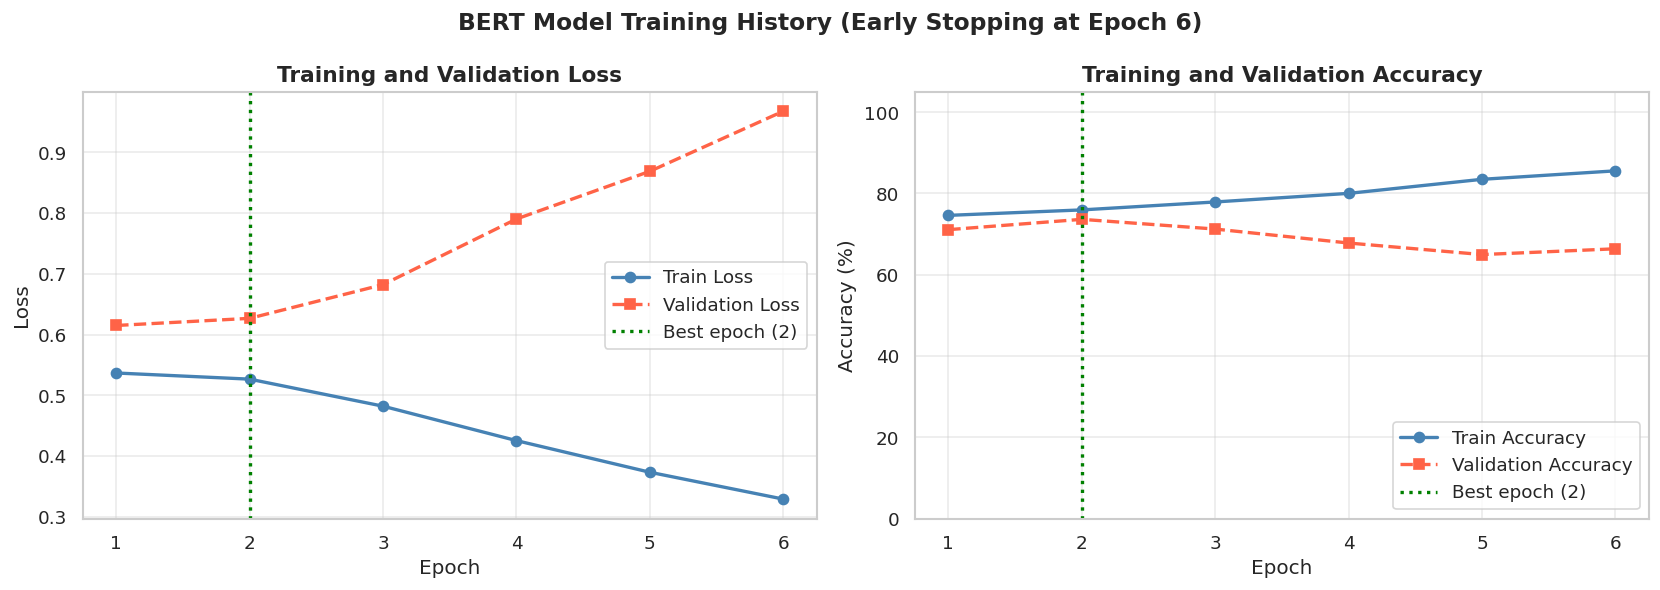

Training curves saved to 'training_curves.png'.


In [ ]:
# Use actual number of epochs that ran, not the max EPOCHS setting
actual_epochs = range(1, len(history['train_loss']) + 1)  # 6 epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss Curves ----
axes[0].plot(actual_epochs, history['train_loss'], 'o-', color='steelblue',
             linewidth=2, markersize=6, label='Train Loss')
axes[0].plot(actual_epochs, history['val_loss'], 's--', color='tomato',
             linewidth=2, markersize=6, label='Validation Loss')
axes[0].axvline(x=2, color='green', linestyle=':', linewidth=2, label='Best epoch (2)')
axes[0].set_title('Training and Validation Loss', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(list(actual_epochs))
axes[0].grid(True, alpha=0.4)

# ---- Accuracy Curves ----
axes[1].plot(actual_epochs, [a * 100 for a in history['train_acc']], 'o-',
             color='steelblue', linewidth=2, markersize=6, label='Train Accuracy')
axes[1].plot(actual_epochs, [a * 100 for a in history['val_acc']], 's--',
             color='tomato', linewidth=2, markersize=6, label='Validation Accuracy')
axes[1].axvline(x=2, color='green', linestyle=':', linewidth=2, label='Best epoch (2)')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].set_xticks(list(actual_epochs))
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.4)

plt.suptitle('BERT Model Training History (Early Stopping at Epoch 6)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()
print("Training curves saved to 'training_curves.png'.")

---
## Section 22: Final Evaluation

Load the best saved model and evaluate it on the held-out test set. Report standard classification metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- Full classification report

In [ ]:
# -------------------------------------------------------
# Load Best Model for Final Evaluation
# -------------------------------------------------------
print("Loading best saved model for final evaluation...")

best_model = BertMemeClassifier(
    bert_model_name=BERT_MODEL,
    num_classes=2,
    dropout_rate=DROPOUT_RATE
)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model = best_model.to(DEVICE)
print("Best model loaded.")

# -------------------------------------------------------
# Run Evaluation on Test Set
# -------------------------------------------------------
test_loss, test_acc, test_preds, test_labels = evaluate(
    best_model, test_loader, criterion, DEVICE
)

# -------------------------------------------------------
# Compute Metrics
# -------------------------------------------------------
precision = precision_score(test_labels, test_preds, average='binary', zero_division=0)
recall    = recall_score(test_labels, test_preds, average='binary', zero_division=0)
f1        = f1_score(test_labels, test_preds, average='binary', zero_division=0)
accuracy  = accuracy_score(test_labels, test_preds)

print("\n" + "=" * 50)
print("FINAL TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Test Loss: {test_loss:.4f}")
print("=" * 50)

print("\nFull Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=['Non-Hateful', 'Hateful'],
    zero_division=0
))

Loading best saved model for final evaluation...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best model loaded.

FINAL TEST SET EVALUATION RESULTS
  Accuracy:  0.7294  (72.94%)
  Precision: 0.5990
  Recall:    0.5475
  F1-Score:  0.5721
  Test Loss: 0.6068

Full Classification Report:
              precision    recall  f1-score   support

 Non-Hateful       0.79      0.82      0.80       896
     Hateful       0.60      0.55      0.57       442

    accuracy                           0.73      1338
   macro avg       0.69      0.68      0.69      1338
weighted avg       0.72      0.73      0.73      1338



---
## Section 23: Confusion Matrix

Visualize the confusion matrix to understand the distribution of correct and incorrect predictions across both classes.

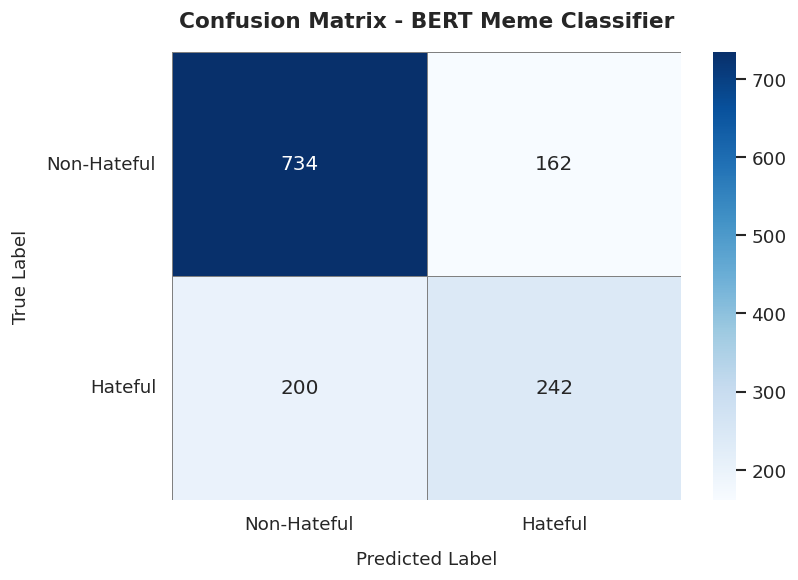

True Negatives  (Non-Hateful correctly classified): 734
False Positives (Non-Hateful classified as Hateful): 162
False Negatives (Hateful classified as Non-Hateful): 200
True Positives  (Hateful correctly classified):      242


In [ ]:
# -------------------------------------------------------
# Compute Confusion Matrix
# -------------------------------------------------------
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hateful', 'Hateful'],
    yticklabels=['Non-Hateful', 'Hateful'],
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    ax=ax
)

ax.set_title('Confusion Matrix - BERT Meme Classifier', fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Predicted Label', fontsize=11, labelpad=10)
ax.set_ylabel('True Label', fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# Print raw confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Non-Hateful correctly classified): {tn}")
print(f"False Positives (Non-Hateful classified as Hateful): {fp}")
print(f"False Negatives (Hateful classified as Non-Hateful): {fn}")
print(f"True Positives  (Hateful correctly classified):      {tp}")

---
## Section 24: Inference Function

Define a `predict_meme()` function that takes raw meme text as input, applies preprocessing and BERT tokenization, runs inference through the trained model, and returns a human-readable prediction.

In [ ]:
def predict_meme(text: str, model: nn.Module = None) -> dict:
    """
    Predict whether a meme text is hateful or non-hateful.

    Parameters
    ----------
    text  : str
        Raw meme text (metadata or OCR-extracted).
    model : nn.Module, optional
        Trained BERT classifier. Defaults to best_model.

    Returns
    -------
    dict with keys:
        'input_text'   : original input text
        'cleaned_text' : preprocessed text fed to model
        'prediction'   : 'Hateful' or 'Non-Hateful'
        'confidence'   : prediction confidence score (0-1)
        'label'        : integer label (0 or 1)
    """
    if model is None:
        model = best_model

    model.eval()

    # ---- Step 1: Clean text ----
    cleaned = clean_text(text)
    if not cleaned:
        cleaned = 'empty'

    # ---- Step 2: Tokenize ----
    encoding = tokenizer(
        cleaned,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    # ---- Step 3: Inference ----
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)

    # ---- Step 4: Compute probabilities ----
    probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    predicted_class = int(np.argmax(probabilities))
    confidence      = float(probabilities[predicted_class])

    label_map = {0: 'Non-Hateful', 1: 'Hateful'}

    return {
        'input_text':   text,
        'cleaned_text': cleaned,
        'prediction':   label_map[predicted_class],
        'confidence':   confidence,
        'label':        predicted_class
    }


print("Inference function 'predict_meme' defined.")

Inference function 'predict_meme' defined.


---
## Section 25: Example Predictions

Run the inference function on a set of example meme texts to demonstrate the model's classification capability.

In [ ]:
# -------------------------------------------------------
# Example Meme Texts for Inference
# -------------------------------------------------------
# These are generic neutral examples for demonstration purposes only.
# The actual classification behavior depends on your trained model.

example_texts = [
    "Have a great day everyone! Spreading positivity.",
    "These people are ruining everything. They should not be here.",
    "When you realize it is already Friday. Best day of the week!",
    "They are inferior and do not belong in our society.",
    "Just smile. Everything will be okay. Stay strong.",
    "Look at these disgusting creatures, always causing trouble.",
    "Hard work pays off. Keep pushing every single day.",
    "Go back to where you came from. Nobody wants you here."
]

print("=" * 70)
print("INFERENCE RESULTS ON EXAMPLE MEME TEXTS")
print("=" * 70)

for i, text in enumerate(example_texts, 1):
    result = predict_meme(text)
    marker = "[H]" if result['label'] == 1 else "[N]"
    print(f"\nExample {i}: {marker} {result['prediction']} ({result['confidence']*100:.1f}% confidence)")
    print(f"  Text: \"{text}\"")

INFERENCE RESULTS ON EXAMPLE MEME TEXTS

Example 1: [N] Non-Hateful (96.0% confidence)
  Text: "Have a great day everyone! Spreading positivity."

Example 2: [N] Non-Hateful (87.6% confidence)
  Text: "These people are ruining everything. They should not be here."

Example 3: [N] Non-Hateful (97.3% confidence)
  Text: "When you realize it is already Friday. Best day of the week!"

Example 4: [N] Non-Hateful (77.0% confidence)
  Text: "They are inferior and do not belong in our society."

Example 5: [N] Non-Hateful (98.0% confidence)
  Text: "Just smile. Everything will be okay. Stay strong."

Example 6: [N] Non-Hateful (84.8% confidence)
  Text: "Look at these disgusting creatures, always causing trouble."

Example 7: [N] Non-Hateful (97.9% confidence)
  Text: "Hard work pays off. Keep pushing every single day."

Example 8: [N] Non-Hateful (88.7% confidence)
  Text: "Go back to where you came from. Nobody wants you here."


---
## Section 26: Save Model

Save the final trained model weights and configuration for future use, deployment, or continued fine-tuning.

In [ ]:
# -------------------------------------------------------
# Save Model Weights
# -------------------------------------------------------
# The best model has already been saved during training.
# This cell also saves the final model state and configuration metadata.

FINAL_MODEL_PATH = 'best_bert_model.pth'

# Ensure the best model file exists
if os.path.exists(best_model_path):
    print(f"Best model already saved at: {best_model_path}")
else:
    # Save current model if best model file is missing
    torch.save(best_model.state_dict(), FINAL_MODEL_PATH)
    print(f"Current model saved to: {FINAL_MODEL_PATH}")

# -------------------------------------------------------
# Save Model Configuration Metadata
# -------------------------------------------------------
config = {
    'bert_model_name': BERT_MODEL,
    'num_classes':     2,
    'dropout_rate':    DROPOUT_RATE,
    'max_len':         MAX_LEN,
    'batch_size':      BATCH_SIZE,
    'epochs_trained':  EPOCHS,
    'learning_rate':   LEARNING_RATE,
    'best_val_acc':    round(best_val_acc, 4),
    'test_accuracy':   round(accuracy, 4),
    'test_f1':         round(f1, 4),
    'label_map':       {0: 'Non-Hateful', 1: 'Hateful'}
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Model configuration saved to: model_config.json")
print("\nSaved configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

print("\nAll model artifacts saved successfully.")

Best model already saved at: best_bert_model.pth
Model configuration saved to: model_config.json

Saved configuration:
  bert_model_name: bert-base-uncased
  num_classes: 2
  dropout_rate: 0.4
  max_len: 128
  batch_size: 16
  epochs_trained: 15
  learning_rate: 2e-05
  best_val_acc: 0.7362
  test_accuracy: 0.7294
  test_f1: 0.5721
  label_map: {0: 'Non-Hateful', 1: 'Hateful'}

All model artifacts saved successfully.


In [ ]:
!ls


best_bert_model.pth   label_distribution.png  text_length_distribution.png
confusion_matrix.png  model_config.json       training_curves.png
drive		      sample_data


In [ ]:
!cp best_bert_model.pth \
/content/drive/MyDrive/Meme_Project/

!cp model_config.json \
/content/drive/MyDrive/Meme_Project/

!cp confusion_matrix.png \
/content/drive/MyDrive/Meme_Project/

!cp training_curves.png \
/content/drive/MyDrive/Meme_Project/

!cp label_distribution.png \
/content/drive/MyDrive/Meme_Project/

!cp text_length_distribution.png \
/content/drive/MyDrive/Meme_Project/

In [ ]:
import os

# Search for all weight files
weight_files = []

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.pt') or file.endswith('.pth'):
            full_path = os.path.join(root, file)
            weight_files.append(full_path)

print("Found weight files:\n")

for w in weight_files:
    print(w)

Found weight files:



---
## Project Summary

This notebook has implemented a complete end-to-end pipeline for hateful meme detection using BERT and OCR.

### Pipeline Recap

| Stage | Component | Purpose |
|---|---|---|
| Data Loading | merged_dataset.csv | Load labeled meme data |
| OCR Extraction | EasyOCR | Extract text embedded in meme images |
| Text Preprocessing | clean_text() | Normalize all text inputs |
| Feature Engineering | combine_texts() | Merge metadata and OCR text |
| Tokenization | BertTokenizer | Convert text to BERT-compatible tokens |
| Modeling | BertMemeClassifier | Fine-tune BERT for binary classification |
| Training | train_one_epoch() | Update model weights via backpropagation |
| Evaluation | evaluate() + metrics | Measure performance on held-out test set |
| Inference | predict_meme() | Classify new meme texts in real time |

### Outputs Produced

- `best_bert_model.pth` - Best model weights (highest validation accuracy)
- `model_config.json` - Model configuration and evaluation results
- `label_distribution.png` - Class balance visualization
- `text_length_distribution.png` - Text length analysis
- `sample_memes.png` - Sample meme image previews
- `training_curves.png` - Training and validation loss/accuracy plots
- `confusion_matrix.png` - Test set confusion matrix

---

### Possible Extensions

- Add image feature extraction using ResNet or ViT for true multimodal fusion
- Experiment with RoBERTa or DeBERTa as stronger BERT alternatives
- Apply class-weighted loss to address label imbalance
- Implement cross-validation for more robust evaluation
- Fine-tune on additional multilingual meme datasets

---

**Project:** BERT-Based Hateful Meme Detection System  
**Framework:** PyTorch + HuggingFace Transformers  
**Model:** bert-base-uncased  
**Task:** Binary Classification (Hateful vs Non-Hateful)